# Representation Learning and Dimensionality Reduction

### Research Question

> Can lower-dimensional representations preserve clinically meaningful information while reducing the complexity of thyroid cancer patient data? Can dimensionality reduction produce a more informative representation of thyroid cancer patients for clustering?

### Objectives

- Understand the motivation behind dimensionality reduction.
- Explore linear and nonlinear representation learning techniques.
- Compare PCA, Kernel PCA, t-SNE, and UMAP.
- Evaluate how dimensionality reduction affects clustering performance.
- Identify informative latent representations that preserve clinically meaningful patient structure.

### Datasets: Two preprocessed feature sets will be investigated.

- Feature Set A: Baseline clinicopathologic characteristics.
- Feature Set B: Baseline clinicopathologic characteristics together with treatment response.



### The goal

> Dimensionality reduction seeks to transform the original feature space into a lower-dimensional representation that preserves as much meaningful information as possible.

> Instead of representing each patient using 36 variables, we may represent them using only 2–5 latent components while retaining most of the important structure.

**This simplified representation enables:**

- easier visualization,
- faster computation,
- reduced redundancy,
- improved clustering,
- improved downstream learning.

### - Import Libraries

In [ ]:
# ==========================================================
# Path Setup
# ==========================================================

import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT / "Notebooks"))
DATA_DIR = PROJECT_ROOT / "Data"

# ==========================================================
# Data Handling
# ==========================================================

import pandas as pd
import numpy as np

# ==========================================================
# Visualization
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

# ==========================================================
# Preprocessing
# ==========================================================

from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline

# ==========================================================
# Dimensionality Reduction
# ==========================================================

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# ==========================================================
# Clustering Algorithms
# ==========================================================

from sklearn.cluster import (
    KMeans,
    AgglomerativeClustering,
    DBSCAN
)

from sklearn.mixture import GaussianMixture

# ==========================================================
# Evaluation Metrics
# ==========================================================

from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

# ==========================================================
# Utilities
# ==========================================================

from kneed import KneeLocator
import joblib

from utils import *

### - Load Datasets

In [3]:
X_A = pd.read_csv(DATA_DIR / "feature_set_A.csv")
X_B = pd.read_csv(DATA_DIR / "feature_set_B.csv")

# External validation only
y = pd.read_csv(DATA_DIR / "recurred.csv")

### 1) Explore PCA
**Goal:** Understand the structure of the data before reducing its dimensionality.

In [4]:
def apply_pca(
    X,
    variance_thresholds=(0.80, 0.90, 0.95)
):
    """
    Fit PCA once and generate reduced datasets for different
    explained variance thresholds.

    Parameters
    ----------
    X : DataFrame or ndarray
        Input feature set.

    variance_thresholds : tuple
        Explained variance thresholds.

    Returns
    -------
    dict
        {
            "full_pca": fitted PCA,
            "summary": DataFrame,
            "transformed": {
                0.80: X_pca80,
                0.90: X_pca90,
                0.95: X_pca95
            },
            "models": {
                0.80: pca80,
                0.90: pca90,
                0.95: pca95
            }
        }
    """

    # --------------------------------------------------
    # Full PCA
    # --------------------------------------------------
    full_pca = PCA()

    full_pca.fit(X)

    explained = full_pca.explained_variance_ratio_

    cumulative = np.cumsum(explained)

    summary = pd.DataFrame({
        "PC": np.arange(1, len(explained)+1),
        "Explained Variance": explained,
        "Cumulative Variance": cumulative
    })

    transformed = {}
    models = {}

    # --------------------------------------------------
    # Reduced datasets
    # --------------------------------------------------
    for threshold in variance_thresholds:

        pca = PCA(
            n_components=threshold
        )

        X_pca = pca.fit_transform(X)

        transformed[threshold] = X_pca
        models[threshold] = pca

    return {
        "full_pca": full_pca,
        "summary": summary,
        "transformed": transformed,
        "models": models
    }

In [5]:
# Apply to both feature sets
pca_results = {
    "A": apply_pca(X_A),
    "B": apply_pca(X_B)
}

In [6]:
# Inspect the summery of features set A
pca_results["A"]["summary"]

,PC,Explained Variance,Cumulative Variance
0,1,4.034901e-01,0.403490
1,2,1.432502e-01,0.546740
2,3,8.784764e-02,0.634588
3,4,5.707114e-02,0.691659
4,5,5.040737e-02,0.742066
5,6,4.112171e-02,0.783188
6,7,3.543912e-02,0.818627
7,8,3.295157e-02,0.851579
8,9,2.543617e-02,0.877015
9,10,1.989046e-02,0.896905


In [25]:
# Inspect the summery of features set B
pca_results["B"]["summary"]

,PC,Explained Variance,Cumulative Variance
0,1,4.032333e-01,0.403233
1,2,1.319080e-01,0.535141
2,3,9.232614e-02,0.627467
3,4,5.149095e-02,0.678958
4,5,4.864615e-02,0.727604
5,6,4.265372e-02,0.770258
6,7,3.676584e-02,0.807024
7,8,3.120599e-02,0.838230
8,9,2.923353e-02,0.867464
9,10,2.250221e-02,0.889966


In [7]:
# Reduced datasets

# Feature set A
X_A_80 = pca_results["A"]["transformed"][0.80]

X_A_90 = pca_results["A"]["transformed"][0.90]

X_A_95 = pca_results["A"]["transformed"][0.95]

# Feature set B
X_B_80 = pca_results["B"]["transformed"][0.80]

X_B_90 = pca_results["B"]["transformed"][0.90]

X_B_95 = pca_results["B"]["transformed"][0.95]


In [11]:
# Inspect One of reduced datasets
pd.DataFrame(X_A_80).head()

,0,1,2,3,4,5,6
0,-2.534793,0.111615,0.522238,0.132129,0.834402,0.367801,1.026945
1,-2.297739,0.530803,0.789142,0.512322,0.534102,0.799819,0.077176
2,-2.554544,0.236454,0.619758,-0.381712,0.410750,0.703582,-0.083711
3,-2.026599,1.934379,1.026804,-0.519966,-0.298853,-0.057101,-0.133897
4,-1.578070,1.924509,1.325854,1.343650,-0.431687,0.158784,-0.074218


In [31]:
def plot_pca_variance(
    pca_results,
    thresholds=(0.80, 0.90, 0.95)
):
    """
    Plot explained variance and cumulative explained variance
    for multiple feature sets.

    Parameters
    ----------
    pca_results : dict
        Output of apply_pca().

    thresholds : tuple
        Variance thresholds to visualize.
    """

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(16,10)
    )

    feature_sets = ["A", "B"]

    for row, fs in enumerate(feature_sets):

        summary = pca_results[fs]["summary"]

        explained = summary["Explained Variance"]
        cumulative = summary["Cumulative Variance"]

        # ----------------------------------------
        # Scree Plot
        # ----------------------------------------
        ax = axes[row,0]

        ax.plot(
            summary["PC"],
            explained,
            marker="o",
            linewidth=2,
            color="palevioletred"
        )

        ax.set_title(
            f"Feature Set {fs} - Scree Plot"
        )

        ax.set_xlabel("Principal Component")
        ax.set_ylabel("Explained Variance Ratio")

        ax.yaxis.set_major_formatter(
            PercentFormatter(1)
        )

        ax.grid(alpha=0.3)

        # ----------------------------------------
        # Cumulative Variance
        # ----------------------------------------
        ax = axes[row,1]

        ax.plot(
            summary["PC"],
            cumulative,
            marker="o",
            linewidth=2
        )

        colors = [
            "#ff0026",
            "#009721",
            "#ff7b00"
        ]

        for threshold, color in zip(thresholds, colors):

            n_components = np.argmax(
                cumulative >= threshold
            ) + 1

            ax.axhline(
                threshold,
                color=color,
                linestyle="--",
                alpha=0.7
            )

            ax.axvline(
                n_components,
                color=color,
                linestyle="--",
                alpha=0.7
            )

            ax.scatter(
                n_components,
                cumulative.iloc[n_components-1],
                color=color,
                s=70,
                zorder=5,
                label=f"{int(threshold*100)}% ({n_components} PCs)"
            )

        ax.set_ylim(0,1.02)

        ax.yaxis.set_major_formatter(
            PercentFormatter(1)
        )

        ax.set_xlabel("Principal Component")

        ax.set_ylabel(
            "Cumulative Explained Variance"
        )

        ax.set_title(
            f"Feature Set {fs} - Cumulative Variance"
        )

        ax.grid(alpha=0.3)

        ax.legend()

    plt.suptitle("Principal Component-Variance Analysis", fontsize=20, y=1.025)
    plt.tight_layout()
    plt.show()

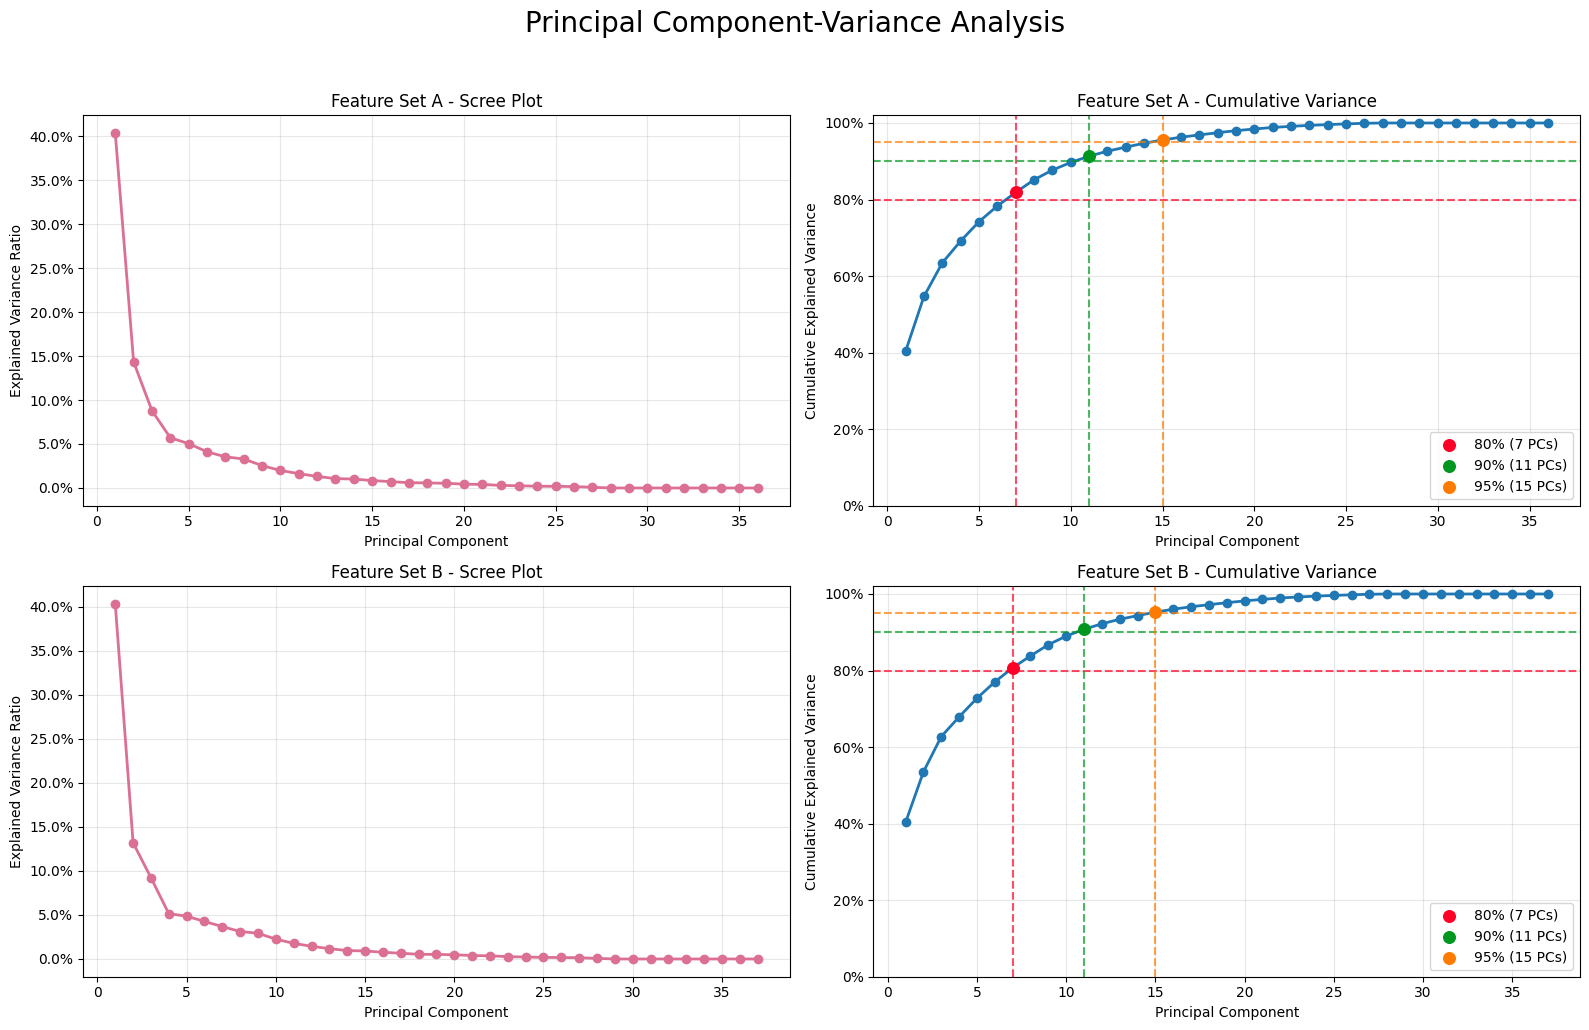

In [32]:
plot_pca_variance(pca_results)

### 2) Build all datasets
Collect every dataset (original + PCA-reduced) into one dictionary.

In [38]:
# Get transformed for each feature sets
transformed_A = pca_results["A"]["transformed"]
transformed_B = pca_results["B"]["transformed"]

# Build up the datasets for all
datasets = {
    "A_Original": X_A,
    "B_Original": X_B
}

for threshold, X in transformed_A.items():
    datasets[f"A_PCA_{int(threshold*100)}"] = X

for threshold, X in transformed_B.items():
    datasets[f"B_PCA_{int(threshold*100)}"] = X



### 3) Define clustering algorithms
We have already determined that `k = 2` works best for the algorithma that need it as an argument.

In [39]:
algorithms = {
    "KMeans": KMeans(
        n_clusters=2,
        random_state=42
    ),

    "Agglomerative": AgglomerativeClustering(
        n_clusters=2
    ),

    "GaussianMixture": GaussianMixture(
        n_components=2,
        random_state=42
    ),

    "DBSCAN": DBSCAN(
        eps=1.5,
        min_samples=5
    )
}


### 4) Benchmark every combination

In [40]:
def evaluate_pca_representations(
    datasets,
    algorithms
):

    results = []

    fitted_models = {}

    clustered_data = {}

    for dataset_name, X in datasets.items():

        for algorithm_name, model in algorithms.items():

            labels = model.fit_predict(X)

            silhouette = silhouette_score(X, labels)

            db = davies_bouldin_score(X, labels)

            ch = calinski_harabasz_score(X, labels)

            results.append({

                "Dataset": dataset_name,

                "Algorithm": algorithm_name,

                "Silhouette": silhouette,

                "Davies-Bouldin": db,

                "Calinski-Harabasz": ch

            })

            fitted_models[f"{algorithm_name}_{dataset_name}"] = model

            clustered_data[f"{algorithm_name}_{dataset_name}"] = labels

    return (
        pd.DataFrame(results),
        fitted_models,
        clustered_data
    )


In [41]:
# Run the function
evaluation_df, models, clusters = evaluate_pca_representations(
    datasets,
    algorithms
)

In [42]:
evaluation_df

,Dataset,Algorithm,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,A_Original,KMeans,0.311612,1.505742,137.325636
1,A_Original,Agglomerative,0.292604,1.620362,119.812667
2,A_Original,GaussianMixture,0.280469,1.699078,103.903917
3,A_Original,DBSCAN,0.138710,2.421144,52.336145
4,B_Original,KMeans,0.317972,1.466397,146.898677
5,B_Original,Agglomerative,0.306432,1.556580,126.827090
6,B_Original,GaussianMixture,0.288087,1.645164,110.072756
7,B_Original,DBSCAN,0.071328,2.108087,32.895007
8,A_PCA_80,KMeans,0.360772,1.290375,181.865768
9,A_PCA_80,Agglomerative,0.341087,1.397400,160.471581


In [ ]:
# ----------------------------------------------------
# Internal Evaluation Comparison
# ----------------------------------------------------

def bar_plot_eval_results(
    evaluation_df,
    metrics,
    titles,
    hue="Dataset"
):

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, metric, title in zip(axes, metrics, titles):

        sns.barplot(
            data=evaluation_df,
            x="Algorithm",
            y=metric,
            hue=hue,
            palette="tab10",
            ax=ax
        )

        ax.set_title(title)

        ax.set_xlabel("")

        ax.grid(alpha=0.4)

        ax.tick_params(
            axis="x",
            rotation=30
        )

    # Show only one legend
    handles, labels = axes[0].get_legend_handles_labels()

    for ax in axes[1:]:

        if ax.get_legend() is not None:
            ax.get_legend().remove()

    axes[0].legend(
        handles,
        labels,
        title=hue,
        bbox_to_anchor=(1.02,1),
        loc="upper left"
    )

    plt.suptitle(
        "Internal Evaluation of Feature Representations",
        fontsize=18
    )

    plt.tight_layout()
    plt.show()

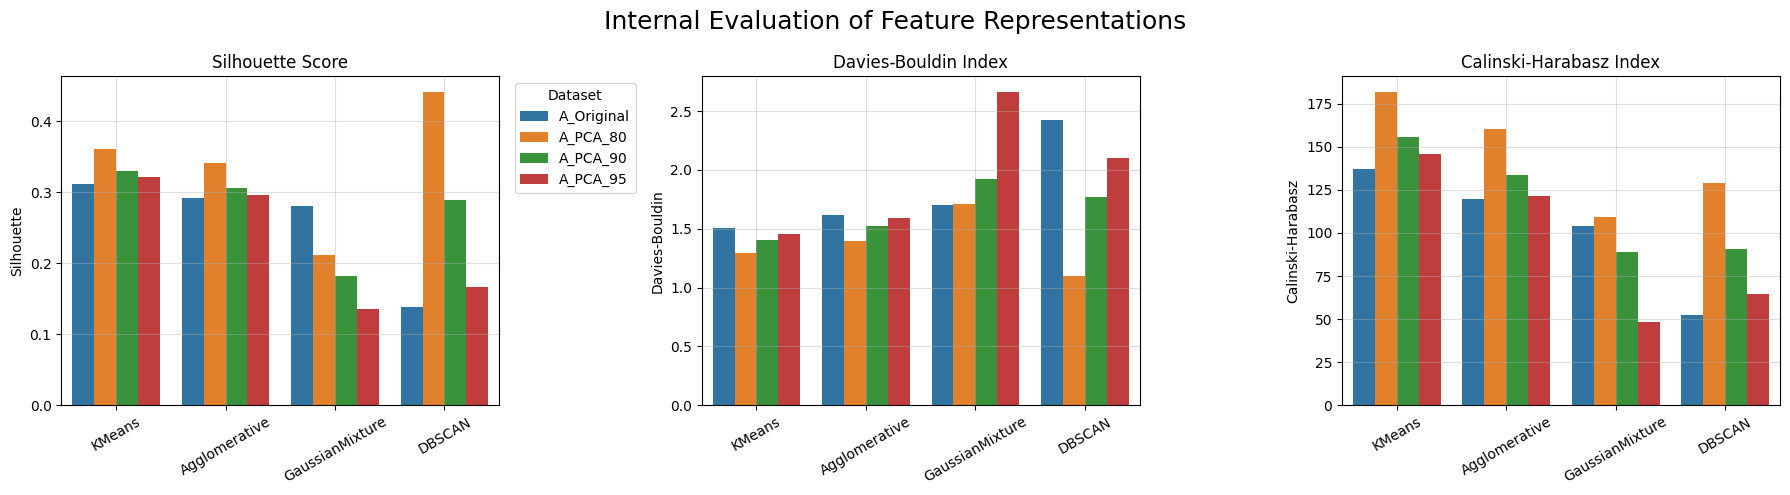

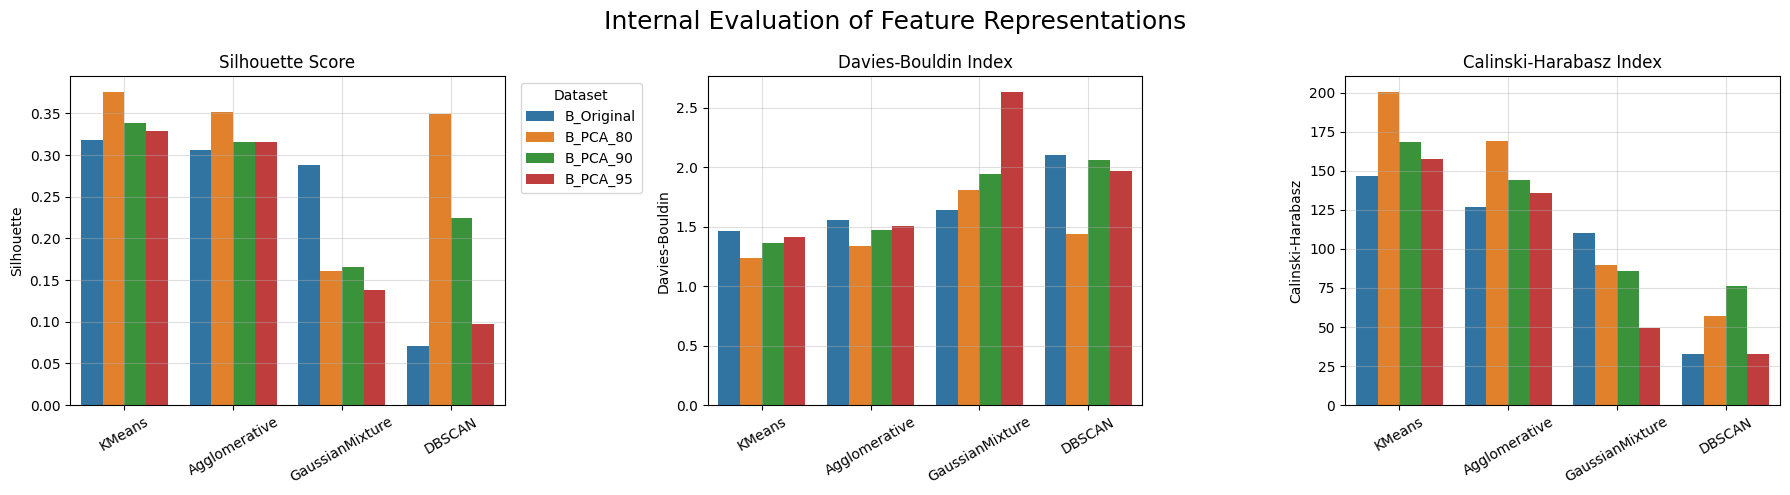

In [54]:
# Get evaluation results of each feature set
eval_df_A = evaluation_df[evaluation_df["Dataset"].str.startswith("A")]
eval_df_B = evaluation_df[evaluation_df["Dataset"].str.startswith("B")]

metrics = [
    "Silhouette",
    "Davies-Bouldin",
    "Calinski-Harabasz"
]

titles = [
    "Silhouette Score",
    "Davies-Bouldin Index",
    "Calinski-Harabasz Index"
]

bar_plot_eval_results(
    eval_df_A,
    metrics,
    titles
)

bar_plot_eval_results(
    eval_df_B,
    metrics,
    titles
)

In [60]:
def plot_silhouette_analysis(
    X_A,
    X_B,
    X_A_clusters,
    X_B_clusters,
    algorithm
):

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    feature_sets = [
        ("A", X_A, X_A_clusters),
        ("B", X_B, X_B_clusters)
    ]

    for ax, (feature_name, X, clusters) in zip(axes, feature_sets):

        # Remove DBSCAN noise points
        if -1 in np.unique(clusters):
            mask = clusters != -1
            X_plot = X.iloc[mask] if hasattr(X, "iloc") else X[mask]
            clusters_plot = clusters[mask]
        else:
            X_plot = X
            clusters_plot = clusters

        # Need at least 2 clusters
        if len(np.unique(clusters_plot)) < 2:
            ax.set_title(f"Feature Set {feature_name}\nNot enough clusters")
            continue

        silhouette_avg = silhouette_score(X_plot, clusters_plot)
        silhouette_vals = silhouette_samples(X_plot, clusters_plot)

        y_lower = 10

        for cluster in np.unique(clusters_plot):

            values = silhouette_vals[clusters_plot == cluster]
            values.sort()

            size = len(values)
            y_upper = y_lower + size

            color = plt.cm.viridis(
                float(cluster) / len(np.unique(clusters_plot))
            )

            ax.fill_betweenx(
                np.arange(y_lower, y_upper),
                0,
                values,
                facecolor=color,
                edgecolor=color,
                alpha=0.8
            )

            ax.text(
                -0.05,
                y_lower + size / 2,
                str(cluster),
                fontsize=10
            )

            y_lower = y_upper + 10

        ax.axvline(
            silhouette_avg,
            color="red",
            linestyle="--",
            linewidth=2,
            label=f"Average = {silhouette_avg:.3f}"
        )

        ax.set_xlim([-0.2, 1])
        ax.set_xlabel("Silhouette Coefficient")
        ax.set_ylabel("Cluster")
        ax.set_title(f"Feature Set {feature_name}\nAverage = {silhouette_avg:.3f}")
        ax.legend()

    fig.suptitle(f"{algorithm} - Silhouette Analysis", fontsize=15)

    plt.tight_layout()
    plt.show()

In [90]:
transformed_eighty_A = pca_results["A"]["transformed"].get(0.8)
transformed_eighty_B = pca_results["B"]["transformed"].get(0.8)
clts_A = clusters["KMeans_A_PCA_80"]
clts_B = clusters["KMeans_B_PCA_80"]


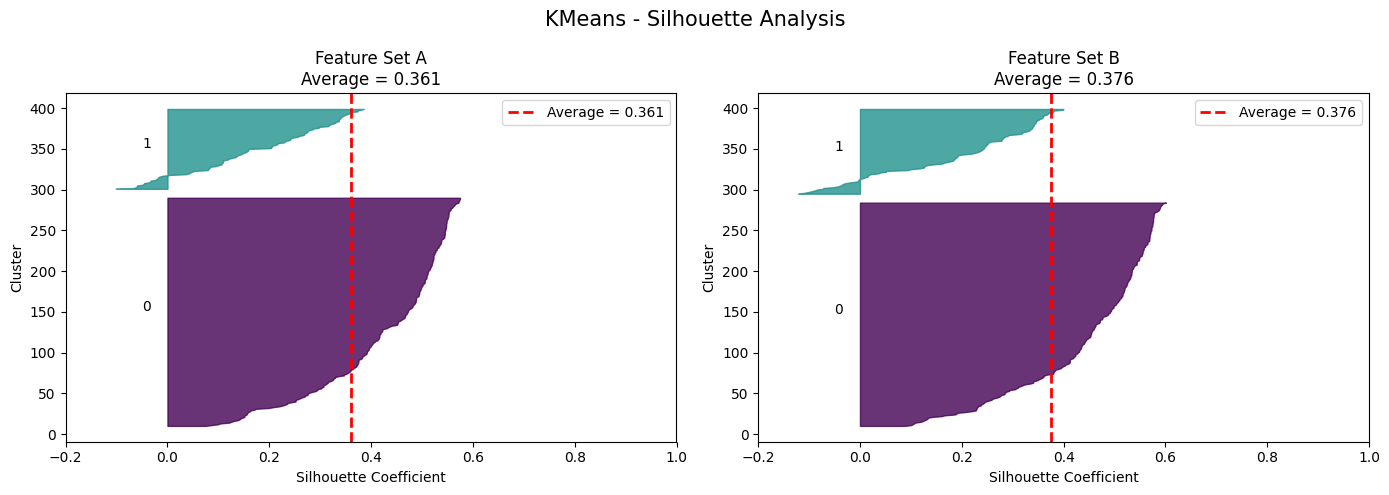

In [91]:

plot_silhouette_analysis(
    transformed_eighty_A,
    transformed_eighty_B,
    clts_A,
    clts_B,
    "KMeans"
)


### 5) Build up results

In [99]:
def resulting(X, cluster_labels):

    # Copy dataset
    results = X.copy()

    # Add cluster labels
    results["Cluster"] = cluster_labels

    # Sample counts
    sample_counts = (
        results["Cluster"]
        .value_counts()
        .sort_index()
    )

    # Cluster characteristics
    cluster_char = (
        results
        .groupby("Cluster")
        .mean(numeric_only=True)
    )

    return results, sample_counts, cluster_char


def apply_resulting(
    X_A,
    X_B,
    clusters_A,
    clusters_B,
    algorithm="KMeans"
):

    results = {}
    sample_counts_rows = []
    cluster_char_rows = []

    datasets = [
        ("A", X_A, clusters_A),
        ("B", X_B, clusters_B)
    ]

    for feature_set, X, cluster_labels in datasets:

        res, count, char = resulting(X, cluster_labels)

        results[f"{algorithm}_{feature_set}"] = res

        # -------------------------
        # Sample counts
        # -------------------------
        count_df = count.reset_index()
        count_df.columns = ["Cluster", "Count"]

        count_df["Algorithm"] = algorithm
        count_df["Feature Set"] = feature_set

        sample_counts_rows.append(count_df)

        # -------------------------
        # Cluster characteristics
        # -------------------------
        char_df = (
            char
            .reset_index()
            .melt(
                id_vars="Cluster",
                var_name="Feature",
                value_name="Mean"
            )
        )

        char_df["Algorithm"] = algorithm
        char_df["Feature Set"] = feature_set

        cluster_char_rows.append(char_df)

    sample_counts_df = pd.concat(sample_counts_rows, ignore_index=True)
    cluster_char_df = pd.concat(cluster_char_rows, ignore_index=True)

    return results, sample_counts_df, cluster_char_df

In [100]:
transformed_eighty_A = pd.DataFrame(
    transformed_eighty_A,
    columns=[f"PC{i+1}" for i in range(transformed_eighty_A.shape[1])]
)

transformed_eighty_B = pd.DataFrame(
    transformed_eighty_B,
    columns=[f"PC{i+1}" for i in range(transformed_eighty_B.shape[1])]
)

results, sample_counts_df, cluster_char_df = apply_resulting(
    transformed_eighty_A,
    transformed_eighty_B,
    clts_A,
    clts_B,
    algorithm="KMeans"
)

#### - Inspect the results dataframe

In [103]:
results["KMeans_A"].head(10)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,Cluster
0,-2.534793,0.111615,0.522238,0.132129,0.834402,0.367801,1.026945,0
1,-2.297739,0.530803,0.789142,0.512322,0.534102,0.799819,0.077176,0
2,-2.554544,0.236454,0.619758,-0.381712,0.410750,0.703582,-0.083711,0
3,-2.026599,1.934379,1.026804,-0.519966,-0.298853,-0.057101,-0.133897,0
4,-1.578070,1.924509,1.325854,1.343650,-0.431687,0.158784,-0.074218,0
5,-1.387204,1.607479,1.322553,1.472564,1.340298,-0.267886,-0.845977,0
6,-2.321537,0.937935,0.754034,-0.456741,0.485592,0.753960,-0.318312,0
7,-2.290572,1.085416,0.823281,-0.450839,0.055948,0.323240,-0.108804,0
8,-2.208080,1.350717,0.886882,-0.472441,-0.054927,0.204384,-0.116646,0
9,-2.389561,0.767056,0.746960,-0.424916,0.188999,0.465869,-0.099394,0


#### - Samples counts in each cluster

In [104]:
sample_counts_df

,Cluster,Count,Algorithm,Feature Set
0,0,281,KMeans,A
1,1,99,KMeans,A
2,0,275,KMeans,B
3,1,105,KMeans,B


In [107]:
# A helper function to get the sample counts of clusters in the corresponding set
def sample_per_set(feature_set):
    return (
        sample_counts_df.loc[
            (sample_counts_df["Feature Set"] == feature_set)
        ]
        .sort_values("Cluster")
        .reset_index(drop=True)
    )

In [ ]:
sample_per_set("A") # Peek

,Cluster,Count,Algorithm,Feature Set
0,0,281,KMeans,A
1,1,99,KMeans,A


In [109]:
# --------------------------------------------------------------------------------------
# Plot sample counts in each cluster in the corresponding set using Bar and Pie plots
# --------------------------------------------------------------------------------------
def plot_sample_counts(algo):
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    feature_sets = ["A", "B"]

    for row, feature_set in enumerate(feature_sets):

        df = sample_per_set(feature_set)

        clusters = df["Cluster"].astype(str)
        counts = df["Count"]

        # -------------------------
        # Bar Plot
        # -------------------------
        ax = axes[row, 0]

        bars = ax.bar(clusters, counts, color="firebrick")

        ax.set_title(f"{algo} - Feature Set {feature_set}")
        ax.set_xlabel("Cluster")
        ax.set_ylabel("Number of Samples")
        ax.grid(alpha=0.5)

        for bar in bars:
            ax.text(
                bar.get_x() + bar.get_width()/2,
                bar.get_height(),
                f"{int(bar.get_height())}",
                ha="center",
                va="bottom",
                fontsize=10
            )

        # -------------------------
        # Pie Chart
        # -------------------------
        ax = axes[row, 1]

        ax.pie(
        counts,
        labels=[f"{i}" for i in clusters],
        autopct="%1.1f%%",
        startangle=90,
        colors=["salmon", "mediumspringgreen", "royalblue", "khaki"],
        pctdistance=1.15,   # percentages farther out
        labeldistance=0.7   # labels closer to center
        )

        ax.set_title(f"{algo} - Feature Set {feature_set}")

    plt.suptitle(f"{algo} Sample Distribution", fontsize=16)

    plt.tight_layout()
    plt.show()

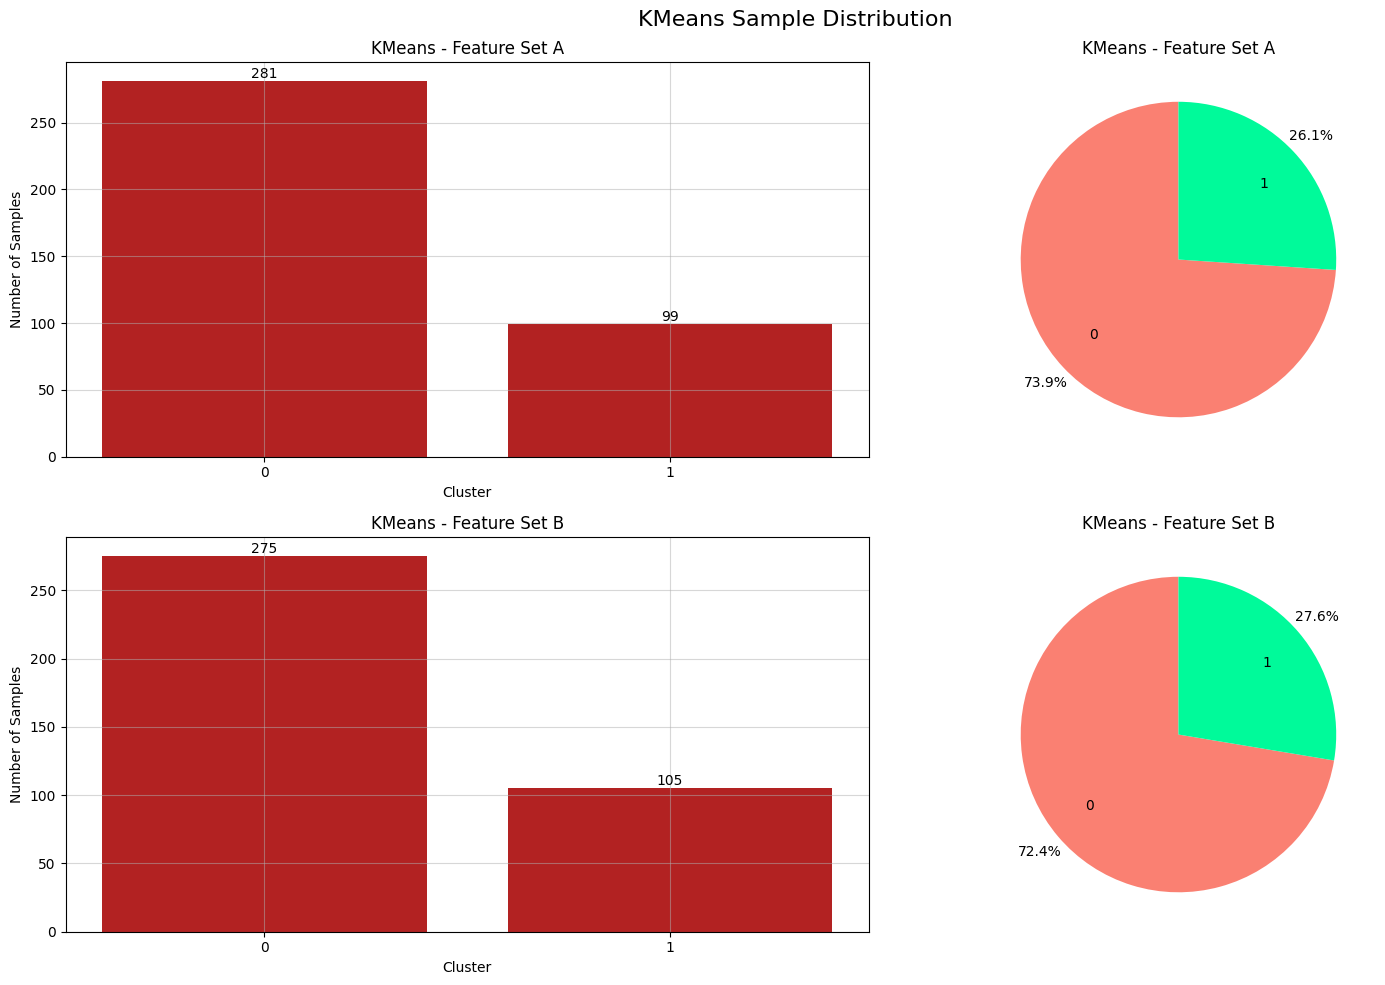

In [110]:
plot_sample_counts("KMeans")

#### - Clusters characteristics

In [105]:
cluster_char_df

,Cluster,Feature,Mean,Algorithm,Feature Set
0,0,PC1,-0.830980,KMeans,A
1,1,PC1,2.358641,KMeans,A
2,0,PC2,0.034261,KMeans,A
3,1,PC2,-0.097247,KMeans,A
4,0,PC3,-0.130746,KMeans,A
5,1,PC3,0.371108,KMeans,A
6,0,PC4,-0.020531,KMeans,A
7,1,PC4,0.058274,KMeans,A
8,0,PC5,0.006825,KMeans,A
9,1,PC5,-0.019373,KMeans,A


In [112]:
# A helper function to get the clusters characteristics in each algorithms and feature set
def clusterChar_per_set(feature_set):
    df = cluster_char_df[
        (cluster_char_df["Feature Set"] == feature_set)
    ]

    return df.pivot(
        index="Cluster",
        columns="Feature",
        values="Mean"
    )

In [113]:
clusterChar_per_set("A")

Feature,PC1,PC2,PC3,PC4,PC5,PC6,PC7
Cluster,,,,,,,
0,-0.830980,0.034261,-0.130746,-0.020531,0.006825,-0.006425,-0.006015
1,2.358641,-0.097247,0.371108,0.058274,-0.019373,0.018238,0.017074


In [114]:

def plot_cluster_char(cluster_char, title=""):

    cluster_char = cluster_char.rename(columns=rename_dict)

    fig, axes = plt.subplots(
        2, 1,
        figsize=(18, 11),
        gridspec_kw={"height_ratios":[2.8,1]}
    )

    # --------------------
    # Bar Plot
    # --------------------
    cluster_char.T.plot(
        kind="bar",
        ax=axes[0],
        width=0.8
    )

    axes[0].set_title(f"{title} Cluster Characteristics")
    axes[0].set_ylabel("Mean Value")
    axes[0].set_xlabel("")
    axes[0].grid(alpha=0.5)
    axes[0].tick_params(axis="x", rotation=90)
    axes[0].legend(title="Cluster")

    # --------------------
    # Heatmap
    # --------------------
    sns.heatmap(
        cluster_char,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        linewidths=0.5,
        annot_kws={"size":7},
        ax=axes[1]
    )

    axes[1].set_title("Heatmap")

    plt.tight_layout()
    plt.show()

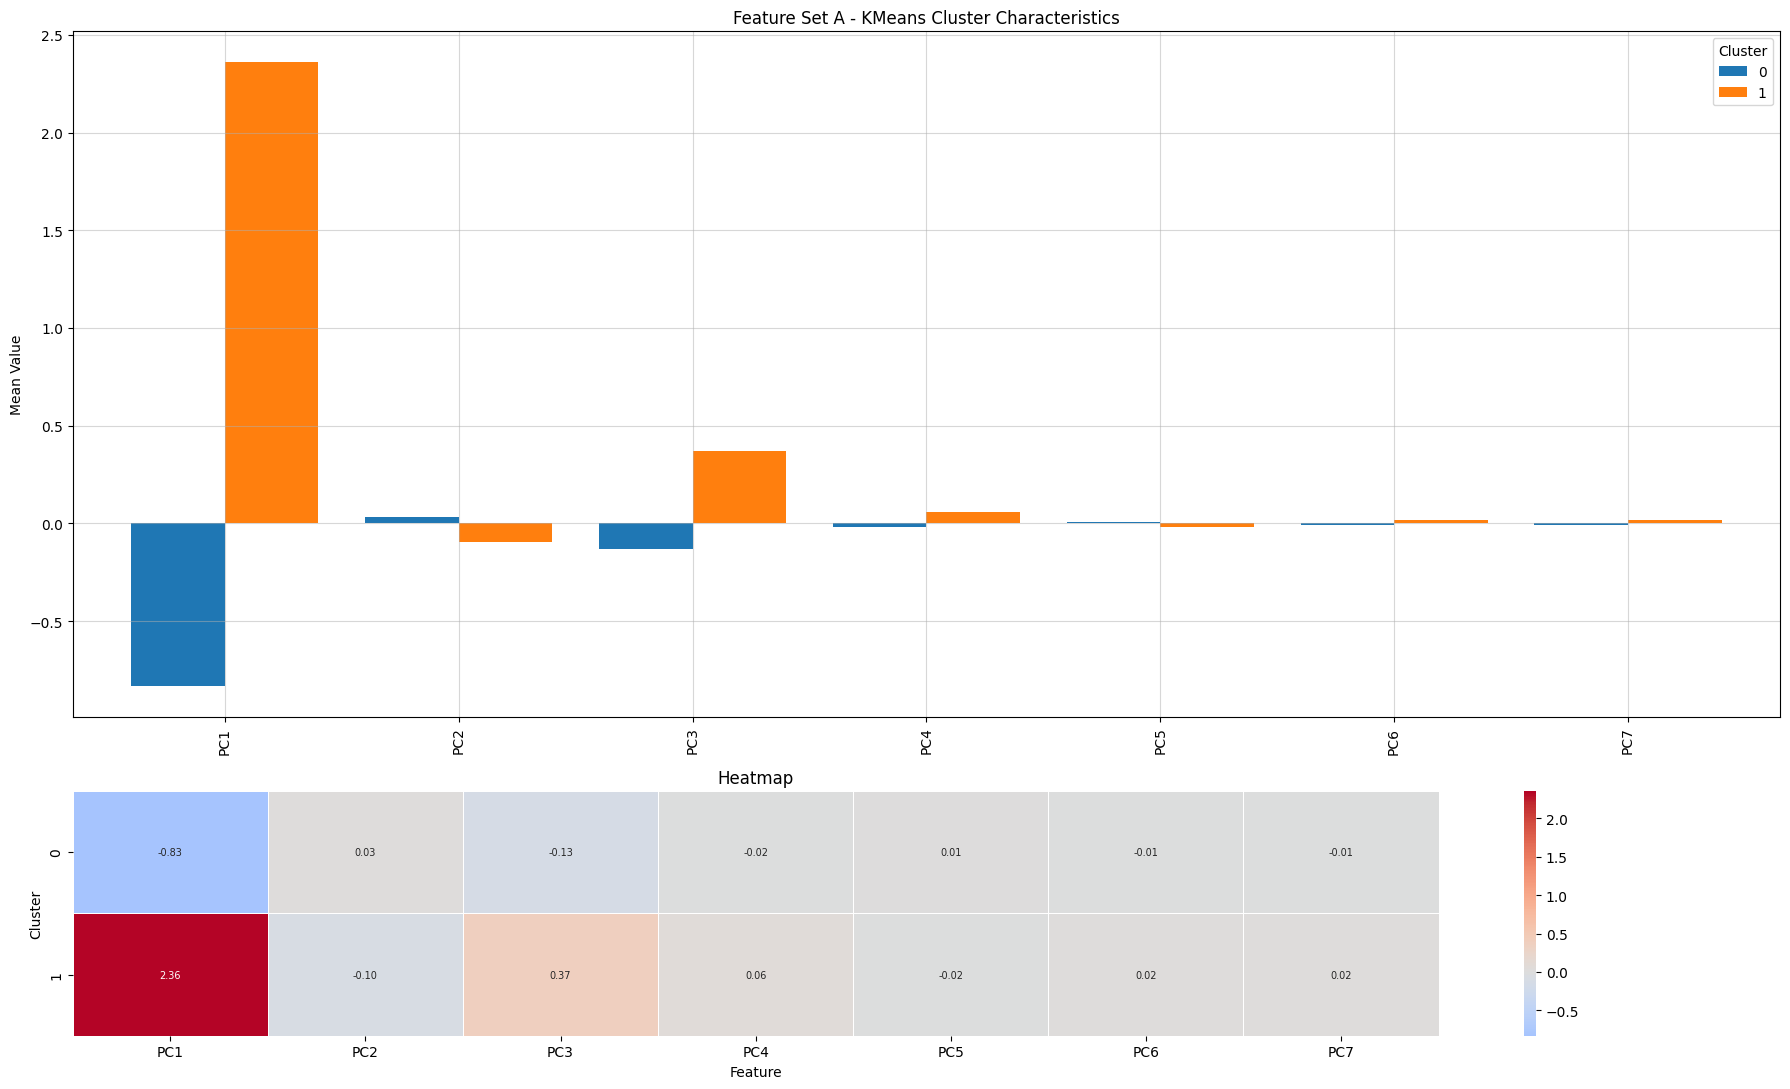

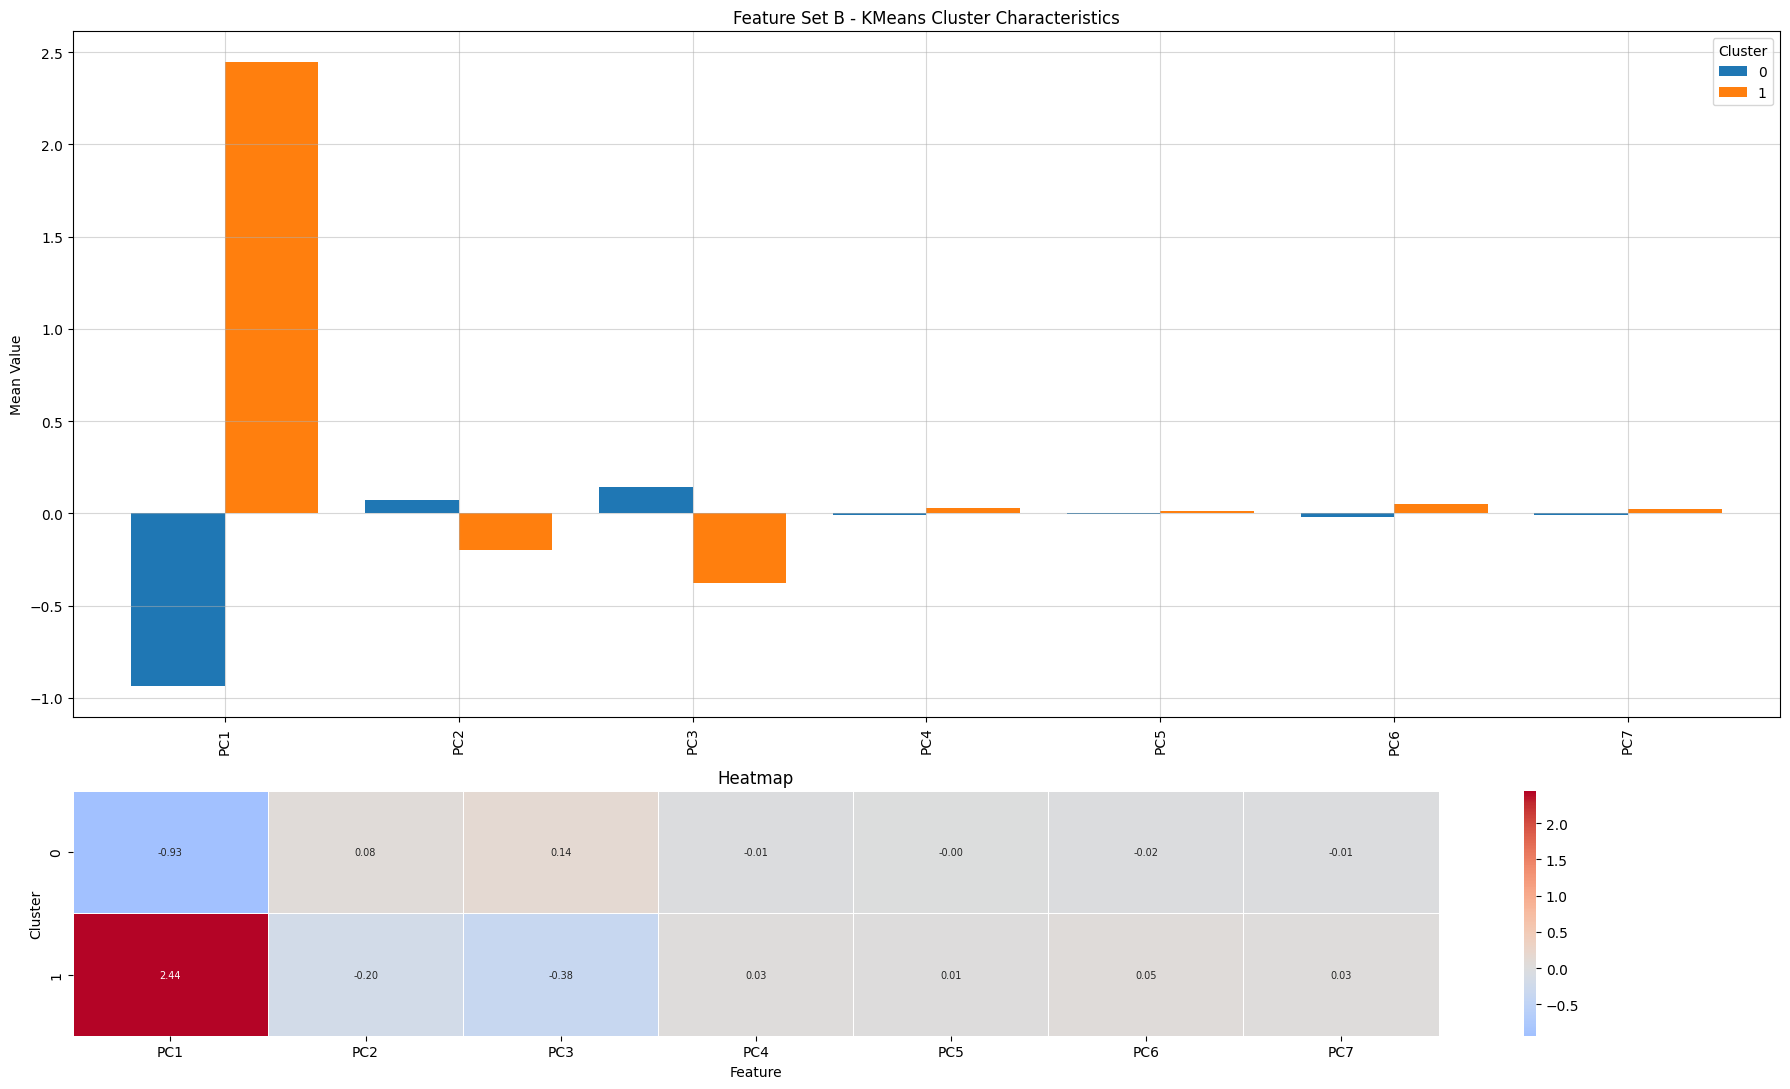

In [ ]:
for feature_set in ["A", "B"]:

        cluster_char = clusterChar_per_set(feature_set)

        plot_cluster_char(
            cluster_char,
            f"Feature Set {feature_set} - KMeans"
        )

### 6) Visualization of PCs

In [116]:
def plot_pca(X, clusters, title=""):

    # PCA
    pca2 = PCA(n_components=2)
    X_pca2 = pca2.fit_transform(X)

    pca3 = PCA(n_components=3)
    X_pca3 = pca3.fit_transform(X)

    # Figure
    fig = plt.figure(figsize=(16,6))

    # -------------------------
    # 2D
    # -------------------------
    ax1 = fig.add_subplot(121)

    scatter = ax1.scatter(
        X_pca2[:, 0],
        X_pca2[:, 1],
        c=clusters,
        cmap="viridis",
        alpha=0.7
    )

    # Centroids in PCA space
    unique_clusters = np.unique(clusters)

    for cluster in unique_clusters:
        centroid = X_pca2[clusters == cluster].mean(axis=0)

        ax1.scatter(
            centroid[0],
            centroid[1],
            marker="X",
            s=250,
            c="red",
            edgecolor="black",
            linewidth=2,
            zorder=5
        )

        ax1.text(
            centroid[0],
            centroid[1],
            f"C{cluster}",
            fontsize=10,
            fontweight="bold",
            ha="center",
            va="center",
            color="white"
        )

    ax1.set_title(
        f"{title} 2 PCs ({pca2.explained_variance_ratio_.sum()*100:.2f}%)"
    )
    ax1.grid(alpha=0.5)
    ax1.set_xlabel("PC1")
    ax1.set_ylabel("PC2")

    # -------------------------
    # 3D
    # -------------------------
    ax2 = fig.add_subplot(122, projection="3d")

    scatter = ax2.scatter(
        X_pca3[:, 0],
        X_pca3[:, 1],
        X_pca3[:, 2],
        c=clusters,
        cmap="viridis",
        alpha=0.7
    )

    for cluster in unique_clusters:
        centroid = X_pca3[clusters == cluster].mean(axis=0)

        ax2.scatter(
            centroid[0],
            centroid[1],
            centroid[2],
            marker="X",
            s=250,
            c="red",
            edgecolor="black",
            linewidth=2
        )

    ax2.set_title(
        f"{title} 3 PCs ({pca3.explained_variance_ratio_.sum()*100:.2f}%)"
    )

    ax2.set_xlabel("PC1")
    ax2.set_ylabel("PC2")
    ax2.set_zlabel("PC3")

    plt.tight_layout()
    plt.show()

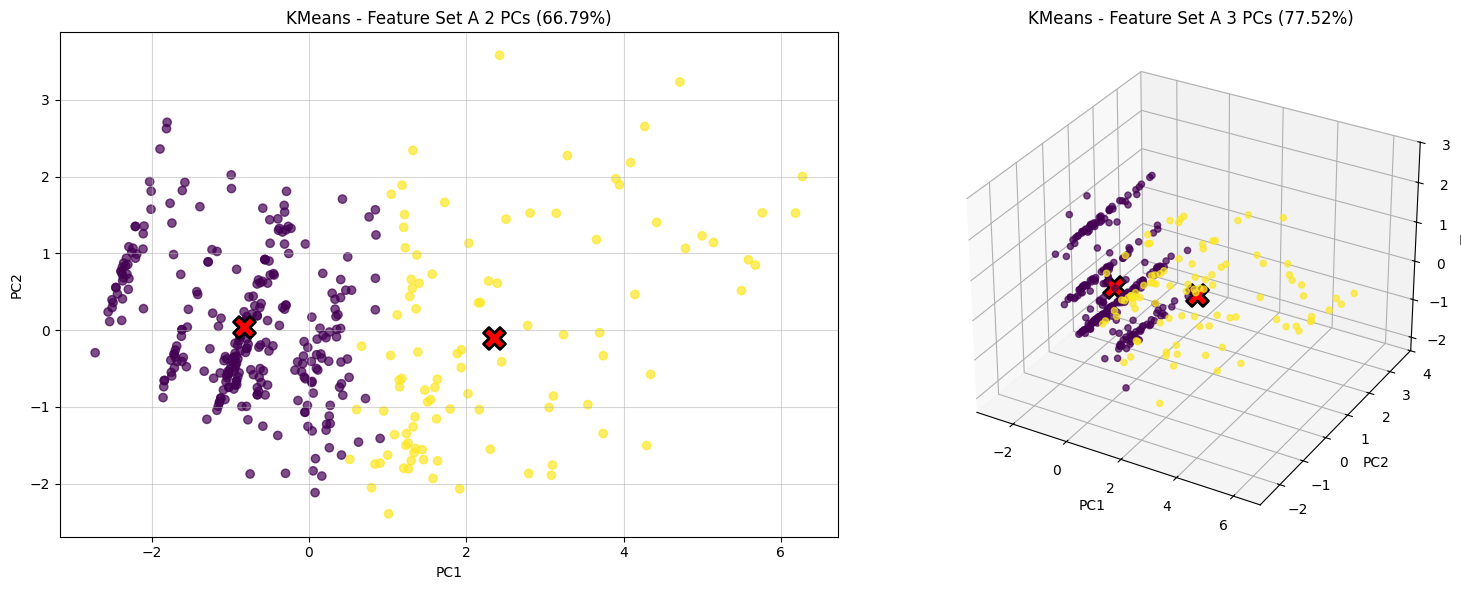

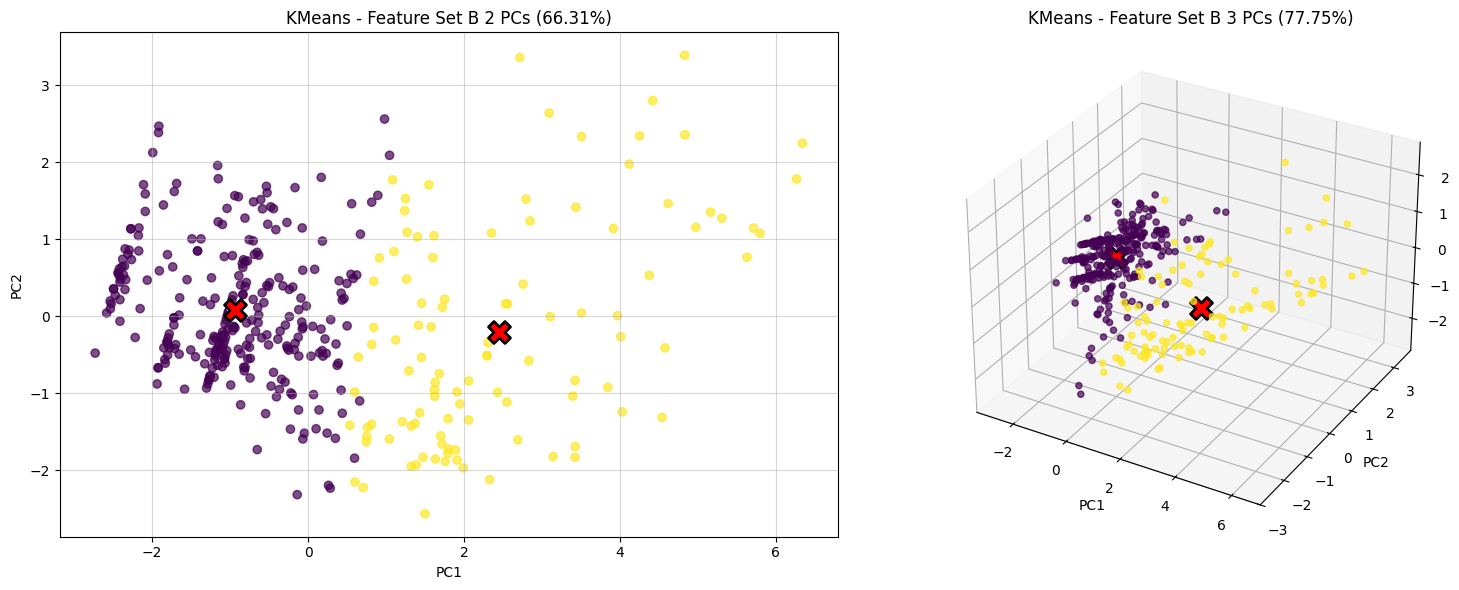

In [117]:
plot_pca(
    transformed_eighty_A,
    clts_A,
    title="KMeans - Feature Set A"
)

plot_pca(
    transformed_eighty_B,
    clts_B,
    title="KMeans - Feature Set B"
)

### 7) External Evaluation

#### - Contingency table / heatmap

In [118]:
def external_validation(results, y, target_name="Recurred"):
    df = results.copy()

    df[target_name] = y

    comparison = (
        pd.crosstab(
            df["Cluster"],
            df[target_name],
            normalize="index"
        )
    )

    comparison_counts = (
        pd.crosstab(
            df["Cluster"],
            df[target_name]
        )
    )

    return comparison, comparison_counts

In [125]:
external_results = {}

for key, rsl in results.items():

    comparison_ratio, comparison_count = external_validation(rsl, y)

    external_results[key] = {
        "ratio": comparison_ratio,
        "count": comparison_count
    }

In [126]:
def plot_external_validation(algo):

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    for col, feature_set in enumerate(["A", "B"]):

        key = f"{algo}_{feature_set}"

        # -------------------------
        # Heatmap (Top Row)
        # -------------------------
        sns.heatmap(
            external_results[key]["ratio"],
            annot=True,
            fmt=".2f",
            cmap="PuBu",
            ax=axes[0, col]
        )

        axes[0, col].set_title(f"{algo} - Feature Set {feature_set}")
        axes[0, col].set_xlabel("Recurred")
        axes[0, col].set_ylabel("Cluster")

        # -------------------------
        # Stacked Bar (Bottom Row)
        # -------------------------
        external_results[key]["ratio"].plot(
            kind="bar",
            stacked=True,
            ax=axes[1, col],
            colormap="Set1"
        )

        axes[1, col].set_title(f"{algo} - Feature Set {feature_set}")
        axes[1, col].grid(alpha=0.5)
        axes[1, col].set_xlabel("Cluster")
        axes[1, col].set_ylabel("Proportion")
        axes[1, col].legend(title="Recurred")

    plt.tight_layout()
    plt.show()

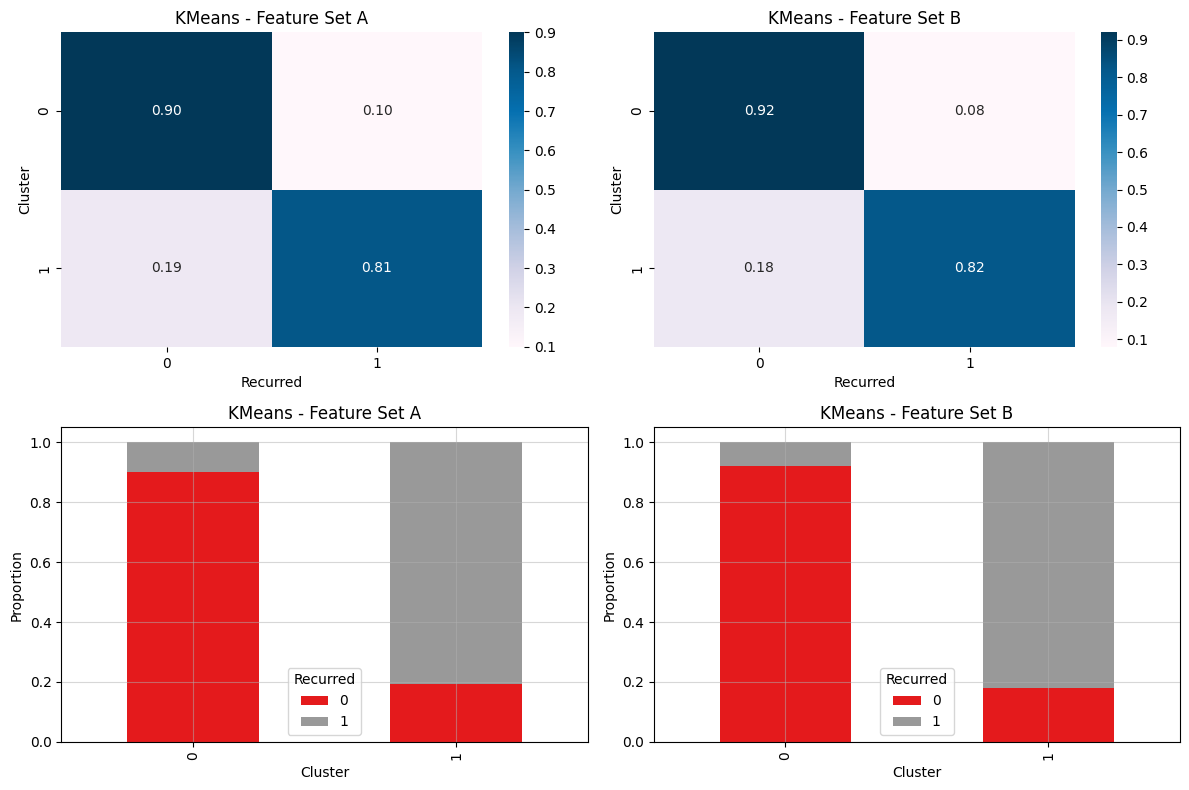

In [121]:
plot_external_validation("KMeans")

### 8) Quantitative external evaluation

#### - Adjusted Rand Index (ARI) & Normalized Mutual Information (NMI)
- **ARI Range**
    - 1.0 → Perfect agreement
    - 0 → Random agreement
    - <0 → Worse than random (rare)

- **NMI Range**
    - 0 → No shared information
    - 1 → Perfect correspondence

In [122]:
def external_evaluation(results_dict, y_true):

    y_true = np.ravel(y_true)

    external_results = []

    for key, df in results_dict.items():

        clusters = df["Cluster"]

        ari = adjusted_rand_score(y_true, clusters)
        nmi = normalized_mutual_info_score(y_true, clusters)

        algorithm, feature_set = key.split("_")

        external_results.append({
            "Algorithm": algorithm,
            "Feature Set": feature_set,
            "ARI": ari,
            "NMI": nmi
        })

    return pd.DataFrame(external_results)

In [123]:
external_df = external_evaluation(results, y)
external_df

,Algorithm,Feature Set,ARI,NMI
0,KMeans,A,0.546320,0.392448
1,KMeans,B,0.599363,0.445904


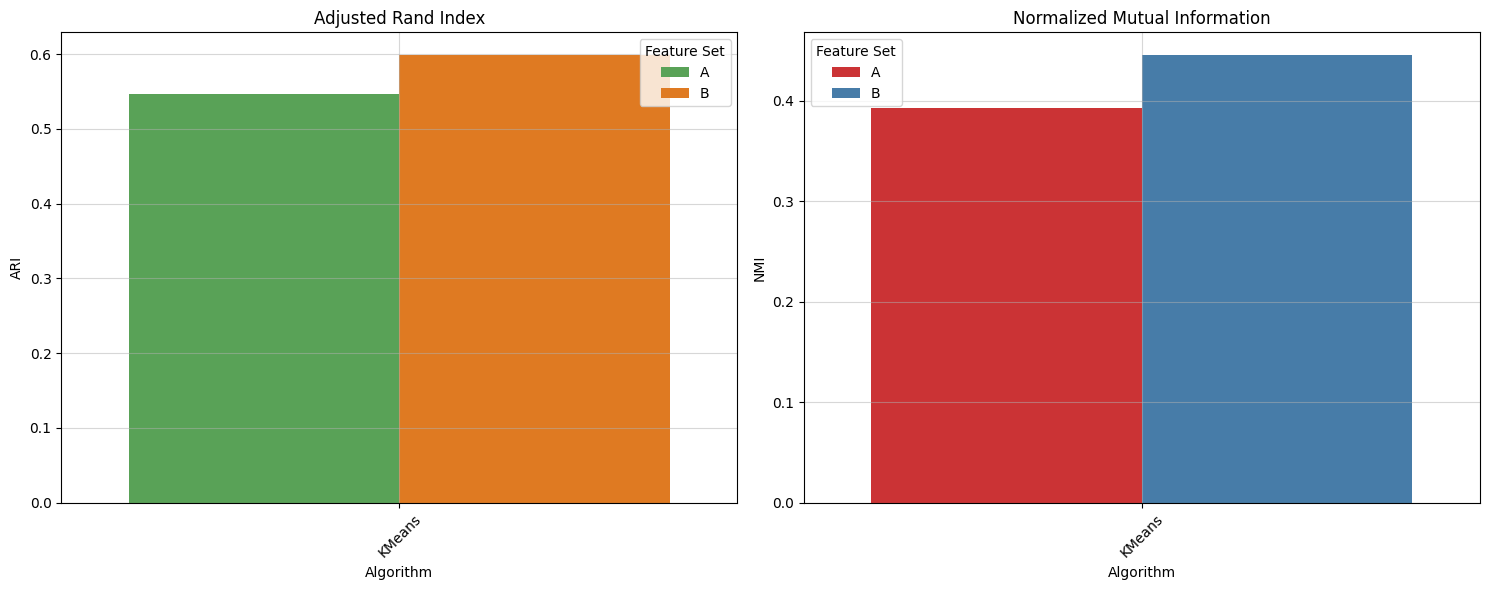

In [124]:
def plot_q_ext_eval(external_df):
    fig, axes = plt.subplots(1, 2, figsize=(15,6))

    sns.barplot(
        data=external_df,
        x="Algorithm",
        y="ARI",
        hue="Feature Set",
        ax=axes[0],
        palette=["#4daf4a", "#ff7802"]
    )

    axes[0].set_title("Adjusted Rand Index")
    axes[0].tick_params(axis="x", rotation=45)
    axes[0].grid(alpha=0.5)

    sns.barplot(
        data=external_df,
        x="Algorithm",
        y="NMI",
        hue="Feature Set",
        ax=axes[1],
        palette=["#e41a1c", "#377eb8"]
    )

    axes[1].set_title("Normalized Mutual Information")
    axes[1].tick_params(axis="x", rotation=45)
    axes[1].grid(alpha=0.5)

    plt.tight_layout()
    plt.show()


plot_q_ext_eval(external_df)

### - Train & Save the best model
- PCA(80%) is best.
- Feature Set B is still slightly better.
- K-Means remains the strongest overall algorithm.

In [8]:
# Train the best model/algorithm
best_model = KMeans(
    n_clusters=2,
    random_state=42
)

best_model.fit(X_B_80)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",2
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [9]:
# Save
joblib.dump(best_model, PROJECT_ROOT / "Models" / "best_kmeans_pca_thyroid.pkl")

['F:\\Desktop\\Projects\\AI-ML-DL\\BioDiscovery-Exploring-Hidden-Patterns-in-Biomedical-Data\\Models\\best_kmeans_pca_thyroid.pkl']

## Final Model Selection

Based on the quantitative and qualitative evaluation throughout this notebook, the final model selected was **K-Means** trained on **Feature Set B after PCA with an 80% explained variance threshold**.

This configuration consistently achieved the best clustering quality among all evaluated PCA representations, producing:

- Highest Silhouette Score
- Lowest Davies-Bouldin Index
- Highest Calinski-Harabasz Score
- Strong agreement with the external recurrence labels (highest ARI and NMI)

After selecting the optimal configuration, the model was trained on the complete transformed dataset and saved for future reuse.

Saving the trained model enables future patient samples to be projected into the same PCA feature space and assigned to one of the discovered patient clusters without retraining the clustering algorithm.

# Conclusion

This notebook investigated whether Principal Component Analysis (PCA) could improve the discovery of clinically meaningful thyroid cancer patient subgroups before clustering.

Three PCA representations were evaluated (80%, 90%, and 95% explained variance) on two feature sets using four clustering algorithms: K-Means, Agglomerative Clustering, Gaussian Mixture Models, and DBSCAN. Their performance was compared using internal clustering metrics (Silhouette Score, Davies-Bouldin Index, and Calinski-Harabasz Score) together with external validation (Adjusted Rand Index and Normalized Mutual Information).

The results showed that dimensionality reduction generally improved clustering quality. In particular, retaining **80% of the explained variance** consistently produced the strongest internal evaluation scores. Feature Set B continued to outperform Feature Set A across nearly every evaluation metric, indicating that preserving the ordinal clinical variables contributed meaningful information even after dimensionality reduction.

Among all evaluated models, **K-Means on Feature Set B with PCA (80% explained variance)** achieved the best overall performance. Compared with clustering on the original feature space, PCA produced more compact and better-separated clusters while maintaining strong agreement with the clinical recurrence labels.

A notable limitation of PCA is the loss of direct feature interpretability. Unlike clustering in the original feature space, where each cluster can be characterized using meaningful clinical variables such as tumor stage, risk level, smoking history, or pathology type, PCA clusters are described by principal components, which are linear combinations of the original features. Consequently, although clustering performance improves, interpreting the clinical meaning of each cluster becomes substantially more challenging.

Overall, this notebook demonstrates that PCA serves as an effective preprocessing technique for clustering biomedical datasets by reducing dimensionality, removing redundancy, and improving cluster quality. At the same time, it highlights the trade-off between predictive clustering performance and clinical interpretability, an important consideration when applying dimensionality reduction methods in healthcare research.